# Next-Day Stock Volatility Forecasting (NNAR-Style)

This notebook builds one-step-ahead forecasts for next-day `volatility_1D` for:
- `CTVA`
- `DDOG`

We train one separate model per stock, compare against a naive baseline, retrain once on train+validation, and then forecast the unseen period sequentially without daily refits.

## Workflow Overview

1. Load and sort data
2. Apply the exact date split logic provided
3. Filter to `CTVA` and `DDOG`
4. Build leakage-safe features for train/validation
5. Train and validate:
   - Naive baseline (`today volatility -> next day volatility`)
   - NNAR-style neural network (single hidden layer)
6. Retrain NNAR on train+validation
7. Forecast unseen one day ahead, sequentially, without refitting
8. Report metrics and plots

## Imports and Reproducibility

In [29]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print(f"Seed set to: {SEED}")

Seed set to: 42


## Paths and Global Configuration

In [30]:
csv_path = "data/sp500_5yr_with_sectors_weights.csv"
unseen_path = "data/sp500_unseen.csv"

symbols_to_model = ["CTVA", "DDOG"]
include_today = True
use_log_volatility = False
n_lags = 21

hidden_units = 32
activation = "relu"
epochs = 100
batch_size = 32
patience = 10

print("csv_path:", csv_path)
print("unseen_path:", unseen_path)
print("symbols:", symbols_to_model)
print("include_today:", include_today)
print("use_log_volatility:", use_log_volatility)

csv_path: data/sp500_5yr_with_sectors_weights.csv
unseen_path: data/sp500_unseen.csv
symbols: ['CTVA', 'DDOG']
include_today: True
use_log_volatility: False


## Load Data and Inspect Raw Structure

In [31]:
df_initial = pd.read_csv(csv_path)
df_initial["Date"] = pd.to_datetime(df_initial["Date"])
df_initial = df_initial.sort_values(["Symbol", "Date"]).copy()

unseen_reference = pd.read_csv(unseen_path)
unseen_reference["Date"] = pd.to_datetime(unseen_reference["Date"])
unseen_reference = unseen_reference.sort_values(["Symbol", "Date"]).copy()

print("Main data shape:", df_initial.shape)
print("Unseen reference shape:", unseen_reference.shape)
print("\nMain columns:")
print(df_initial.columns.tolist())

Main data shape: (626169, 10)
Unseen reference shape: (125248, 10)

Main columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Symbol', 'Security', 'Sector', 'Weight']


In [32]:
print("Main date range:", df_initial["Date"].min().date(), "to", df_initial["Date"].max().date())
print("Unseen reference date range:", unseen_reference["Date"].min().date(), "to", unseen_reference["Date"].max().date())
print("\nHead of main data:")
display(df_initial.head(3))

Main date range: 2021-03-22 to 2026-03-20
Unseen reference date range: 2025-03-21 to 2026-03-20

Head of main data:


,Date,Open,High,Low,Close,Volume,Symbol,Security,Sector,Weight
11304,2021-03-22,118.071328,119.675641,117.636428,119.463020,1772900,A,Agilent Technologies,Health Care,0.0005
11305,2021-03-23,119.018449,120.062218,117.394811,117.887703,1338300,A,Agilent Technologies,Health Care,0.0005
11306,2021-03-24,118.022998,118.834813,116.689291,116.785934,1477500,A,Agilent Technologies,Health Care,0.0005


## Exact Date Split Logic (As Requested)

The following cell uses the split code exactly as provided.

In [33]:
df = pd.read_csv(csv_path)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Symbol', 'Date']).copy()

unseen_end = df['Date'].max().normalize()
unseen_start = unseen_end - pd.DateOffset(years=1) + pd.Timedelta(days=1)
val_end = unseen_start - pd.Timedelta(days=1)
val_start = val_end - pd.DateOffset(years=1) + pd.Timedelta(days=1)
train_end = val_start - pd.Timedelta(days=1)
data_start = train_end - pd.DateOffset(years=3) + pd.Timedelta(days=1)

print("data_start   :", data_start.date())
print("train_end    :", train_end.date())
print("val_start    :", val_start.date())
print("val_end      :", val_end.date())
print("unseen_start :", unseen_start.date())
print("unseen_end   :", unseen_end.date())

data_start   : 2021-03-21
train_end    : 2024-03-20
val_start    : 2024-03-21
val_end      : 2025-03-20
unseen_start : 2025-03-21
unseen_end   : 2026-03-20


## Filter to CTVA and DDOG

In [34]:
df = df[df["Symbol"].isin(symbols_to_model)].copy()
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

print("Filtered shape:", df.shape)
print("Symbols in filtered data:", sorted(df["Symbol"].unique()))

display(
    df.groupby("Symbol")
      .agg(rows=("Date", "size"), min_date=("Date", "min"), max_date=("Date", "max"))
      .reset_index()
)

Filtered shape: (2512, 10)
Symbols in filtered data: ['CTVA', 'DDOG']


,Symbol,rows,min_date,max_date
0,CTVA,1256,2021-03-22,2026-03-20
1,DDOG,1256,2021-03-22,2026-03-20


In [35]:
unseen_reference_small = unseen_reference[unseen_reference["Symbol"].isin(symbols_to_model)].copy()
print("Filtered unseen reference shape:", unseen_reference_small.shape)

display(
    unseen_reference_small.groupby("Symbol")
    .agg(rows=("Date", "size"), min_date=("Date", "min"), max_date=("Date", "max"))
    .reset_index()
)

Filtered unseen reference shape: (502, 10)


,Symbol,rows,min_date,max_date
0,CTVA,251,2025-03-21,2026-03-20
1,DDOG,251,2025-03-21,2026-03-20


## Leakage-Safe Stage Separation

We isolate unseen data first.  
Model development uses only pre-unseen data.

In [36]:
pre_unseen_raw = df[(df["Date"] >= data_start) & (df["Date"] <= val_end)].copy()
unseen_raw_from_split = df[(df["Date"] >= unseen_start) & (df["Date"] <= unseen_end)].copy()
unseen_raw = unseen_reference_small[
    (unseen_reference_small["Date"] >= unseen_start) & (unseen_reference_small["Date"] <= unseen_end)
].copy()

print("pre_unseen_raw shape:", pre_unseen_raw.shape)
print("unseen_raw_from_split shape:", unseen_raw_from_split.shape)
print("unseen_raw (from unseen_path) shape:", unseen_raw.shape)

print("\npre_unseen date range:", pre_unseen_raw["Date"].min().date(), "to", pre_unseen_raw["Date"].max().date())
print("unseen_from_split date range:", unseen_raw_from_split["Date"].min().date(), "to", unseen_raw_from_split["Date"].max().date())
print("unseen_from_file date range :", unseen_raw["Date"].min().date(), "to", unseen_raw["Date"].max().date())

split_counts = unseen_raw_from_split.groupby("Symbol").size().rename("rows_split")
file_counts = unseen_raw.groupby("Symbol").size().rename("rows_file")
print("\nUnseen row-count comparison by symbol:")
display(pd.concat([split_counts, file_counts], axis=1).fillna(0).astype(int).reset_index())

pre_unseen_raw shape: (2010, 10)
unseen_raw_from_split shape: (502, 10)
unseen_raw (from unseen_path) shape: (502, 10)

pre_unseen date range: 2021-03-22 to 2025-03-20
unseen_from_split date range: 2025-03-21 to 2026-03-20
unseen_from_file date range : 2025-03-21 to 2026-03-20

Unseen row-count comparison by symbol:


,Symbol,rows_split,rows_file
0,CTVA,251,251
1,DDOG,251,251


## Feature Engineering Functions

Required features:
- `log_return_1D`
- `volatility_1D = abs(log_return_1D)`
- `volume_change_1D` (daily log-volume change)
- `log_return_5D`, `log_return_21D` (rolling sums)
- `volatility_5D`, `volatility_21D` (rolling std of daily log returns)
- `volume_change_5D`, `volume_change_21D` (rolling sums of daily log-volume changes)
- `target_next_volatility_1D` (next day volatility)
- `volatility_1D_lag1` through `volatility_1D_lag21`

In [37]:
def create_engineered_features(
    input_df: pd.DataFrame,
    include_today: bool = True,
    use_log_volatility: bool = False,
    n_lags: int = 21
) -> pd.DataFrame:
    out_frames = []

    for symbol, g in input_df.sort_values(["Symbol", "Date"]).groupby("Symbol", sort=False):
        g = g.copy()
        g["Close"] = g["Close"].astype(float)
        g["Volume"] = g["Volume"].astype(float)

        # Daily log return from Close
        g["log_return_1D"] = np.log(g["Close"]).diff()

        # Daily volatility proxy
        g["volatility_1D"] = g["log_return_1D"].abs()
        if use_log_volatility:
            g["volatility_1D"] = np.log1p(g["volatility_1D"])

        # Daily log volume change
        log_volume = np.log(g["Volume"].replace(0, np.nan))
        g["volume_change_1D"] = log_volume.diff()

        # Rolling features
        g["log_return_5D"] = g["log_return_1D"].rolling(5, min_periods=5).sum()
        g["log_return_21D"] = g["log_return_1D"].rolling(21, min_periods=21).sum()

        g["volatility_5D"] = g["log_return_1D"].rolling(5, min_periods=5).std()
        g["volatility_21D"] = g["log_return_1D"].rolling(21, min_periods=21).std()

        g["volume_change_5D"] = g["volume_change_1D"].rolling(5, min_periods=5).sum()
        g["volume_change_21D"] = g["volume_change_1D"].rolling(21, min_periods=21).sum()

        # NNAR-style lag features
        lag_shift_base = 0 if include_today else 1
        for lag in range(1, n_lags + 1):
            g[f"volatility_1D_lag{lag}"] = g["volatility_1D"].shift(lag + lag_shift_base)

        # Forecast target: next-day volatility
        g["target_next_volatility_1D"] = g["volatility_1D"].shift(-1)

        out_frames.append(g)

    engineered = pd.concat(out_frames, axis=0).sort_values(["Symbol", "Date"]).reset_index(drop=True)
    return engineered

In [38]:
base_feature_cols = [
    "log_return_1D",
    "volatility_1D",
    "volume_change_1D",
    "log_return_5D",
    "log_return_21D",
    "volatility_5D",
    "volatility_21D",
    "volume_change_5D",
    "volume_change_21D",
]

lag_feature_cols = [f"volatility_1D_lag{i}" for i in range(1, n_lags + 1)]
feature_cols = base_feature_cols + lag_feature_cols
target_col = "target_next_volatility_1D"

print("Number of model features:", len(feature_cols))
print("First 10 features:", feature_cols)

Number of model features: 30
First 10 features: ['log_return_1D', 'volatility_1D', 'volume_change_1D', 'log_return_5D', 'log_return_21D', 'volatility_5D', 'volatility_21D', 'volume_change_5D', 'volume_change_21D', 'volatility_1D_lag1', 'volatility_1D_lag2', 'volatility_1D_lag3', 'volatility_1D_lag4', 'volatility_1D_lag5', 'volatility_1D_lag6', 'volatility_1D_lag7', 'volatility_1D_lag8', 'volatility_1D_lag9', 'volatility_1D_lag10', 'volatility_1D_lag11', 'volatility_1D_lag12', 'volatility_1D_lag13', 'volatility_1D_lag14', 'volatility_1D_lag15', 'volatility_1D_lag16', 'volatility_1D_lag17', 'volatility_1D_lag18', 'volatility_1D_lag19', 'volatility_1D_lag20', 'volatility_1D_lag21']


## Train/Validation Feature Creation (Pre-Unseen Only)

Per leakage rules:
1. Feature engineering is done on the full pre-unseen block (chronological, per stock).
2. Then we split engineered data into train and validation by date.

In [39]:
pre_unseen_features = create_engineered_features(
    pre_unseen_raw,
    include_today=include_today,
    use_log_volatility=use_log_volatility,
    n_lags=n_lags
)

print("pre_unseen_features shape:", pre_unseen_features.shape)
display(pre_unseen_features.head(3))

pre_unseen_features shape: (2010, 41)


,Date,Open,High,Low,Close,Volume,Symbol,Security,Sector,Weight,...,volatility_1D_lag13,volatility_1D_lag14,volatility_1D_lag15,volatility_1D_lag16,volatility_1D_lag17,volatility_1D_lag18,volatility_1D_lag19,volatility_1D_lag20,volatility_1D_lag21,target_next_volatility_1D
0,2021-03-22,45.065343,45.406174,44.355280,44.781319,3358900.0,CTVA,Corteva,Materials,0.0009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.031135
1,2021-03-23,44.203794,44.497288,43.143434,43.408524,4287200.0,CTVA,Corteva,Materials,0.0009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007388
2,2021-03-24,43.711480,44.317403,43.541068,43.730415,3425200.0,CTVA,Corteva,Materials,0.0009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.012693


In [40]:
model_ready_pre_unseen = pre_unseen_features.dropna(subset=feature_cols + [target_col]).copy()
print("model_ready_pre_unseen shape:", model_ready_pre_unseen.shape)

train_df = model_ready_pre_unseen[
    (model_ready_pre_unseen["Date"] >= data_start) & (model_ready_pre_unseen["Date"] <= train_end)
].copy()

val_df = model_ready_pre_unseen[
    (model_ready_pre_unseen["Date"] >= val_start) & (model_ready_pre_unseen["Date"] <= val_end)
].copy()

print("train_df shape:", train_df.shape)
print("val_df shape  :", val_df.shape)

display(
    train_df.groupby("Symbol")
    .agg(rows=("Date", "size"), min_date=("Date", "min"), max_date=("Date", "max"))
    .reset_index()
)
display(
    val_df.groupby("Symbol")
    .agg(rows=("Date", "size"), min_date=("Date", "min"), max_date=("Date", "max"))
    .reset_index()
)

model_ready_pre_unseen shape: (1964, 41)
train_df shape: (1466, 41)
val_df shape  : (498, 41)


,Symbol,rows,min_date,max_date
0,CTVA,733,2021-04-22,2024-03-20
1,DDOG,733,2021-04-22,2024-03-20


,Symbol,rows,min_date,max_date
0,CTVA,249,2024-03-21,2025-03-19
1,DDOG,249,2024-03-21,2025-03-19


## Metrics and Model Helpers

In [41]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1e-8, denom)
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / denom)


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y_true, y_pred)

    if len(y_true) > 1 and np.std(y_true) > 0 and np.std(y_pred) > 0:
        corr = float(np.corrcoef(y_true, y_pred)[0, 1])
    else:
        corr = np.nan

    return {
        "RMSE": rmse,
        "MAE": float(mae),
        "MSE": float(mse),
        "Corr": corr,
        "sMAPE": float(smape(y_true, y_pred)),
    }


def build_nnar_model(input_dim, hidden_units=32, activation="relu"):
    model = Sequential([
        Dense(hidden_units, activation=activation, input_shape=(input_dim,)),
        Dense(1, activation="linear")
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(), loss="mse")
    return model

## Validation Stage: Baseline and NNAR (Per Stock)

Scaling rule:
- Fit `StandardScaler` on train only (per stock), then transform train + validation.

In [42]:
validation_records = []
validation_predictions = []
fitted_scalers_val = {}
fitted_models_val = {}
histories_val = {}

for symbol in symbols_to_model:
    print(f"\n--- Validation modeling for {symbol} ---")
    train_s = train_df[train_df["Symbol"] == symbol].sort_values("Date").copy()
    val_s = val_df[val_df["Symbol"] == symbol].sort_values("Date").copy()

    print("Train rows:", len(train_s), "| Validation rows:", len(val_s))

    X_train = train_s[feature_cols].values
    y_train = train_s[target_col].values
    X_val = val_s[feature_cols].values
    y_val = val_s[target_col].values

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    naive_pred = val_s["volatility_1D"].values
    naive_metrics = compute_metrics(y_val, naive_pred)
    validation_records.append({
        "Stage": "Validation",
        "Symbol": symbol,
        "Model": "Naive(today_vol)",
        **naive_metrics
    })

    model = build_nnar_model(
        input_dim=X_train_scaled.shape[1],
        hidden_units=hidden_units,
        activation=activation
    )

    es = EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[es],
        verbose=0
    )

    nnar_pred = model.predict(X_val_scaled, verbose=0).ravel()
    nnar_metrics = compute_metrics(y_val, nnar_pred)
    validation_records.append({
        "Stage": "Validation",
        "Symbol": symbol,
        "Model": "NNAR(1 hidden layer)",
        **nnar_metrics
    })

    val_pred_df = val_s[["Date", "Symbol", target_col, "volatility_1D"]].copy()
    val_pred_df["pred_naive"] = naive_pred
    val_pred_df["pred_nnar"] = nnar_pred
    val_pred_df.rename(columns={target_col: "actual"}, inplace=True)
    validation_predictions.append(val_pred_df)

    fitted_scalers_val[symbol] = scaler
    fitted_models_val[symbol] = model
    histories_val[symbol] = history

    print("Best validation loss epoch:", np.argmin(history.history["val_loss"]) + 1)


--- Validation modeling for CTVA ---
Train rows: 733 | Validation rows: 249


E0000 00:00:1775714819.647161 18610519 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1775714827.426482 18610519 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type

Best validation loss epoch: 100

--- Validation modeling for DDOG ---
Train rows: 733 | Validation rows: 249
Best validation loss epoch: 100


E0000 00:00:1775714833.507326 18610519 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [43]:
validation_metrics_df = pd.DataFrame(validation_records)
validation_predictions_df = pd.concat(validation_predictions, axis=0).sort_values(["Symbol", "Date"]).reset_index(drop=True)

print("Validation metrics:")
display(validation_metrics_df.sort_values(["Symbol", "Model"]))

print("Validation predictions head:")
display(validation_predictions_df.head(5))

Validation metrics:


,Stage,Symbol,Model,RMSE,MAE,MSE,Corr,sMAPE
1,Validation,CTVA,NNAR(1 hidden layer),0.073393,0.058113,0.005387,0.053530,163.292659
0,Validation,CTVA,Naive(today_vol),0.014867,0.010580,0.000221,-0.032664,95.464999
3,Validation,DDOG,NNAR(1 hidden layer),0.073129,0.057491,0.005348,0.029760,153.250588
2,Validation,DDOG,Naive(today_vol),0.022630,0.016269,0.000512,0.122137,91.981621


Validation predictions head:


,Date,Symbol,actual,volatility_1D,pred_naive,pred_nnar
0,2024-03-21,CTVA,0.012810,0.000897,0.000897,-0.006783
1,2024-03-22,CTVA,0.010118,0.012810,0.012810,0.104635
2,2024-03-25,CTVA,0.011972,0.010118,0.010118,-0.041750
3,2024-03-26,CTVA,0.012357,0.011972,0.011972,0.042590
4,2024-03-27,CTVA,0.011686,0.012357,0.012357,-0.130679


## Validation Plots: Actual vs Predicted

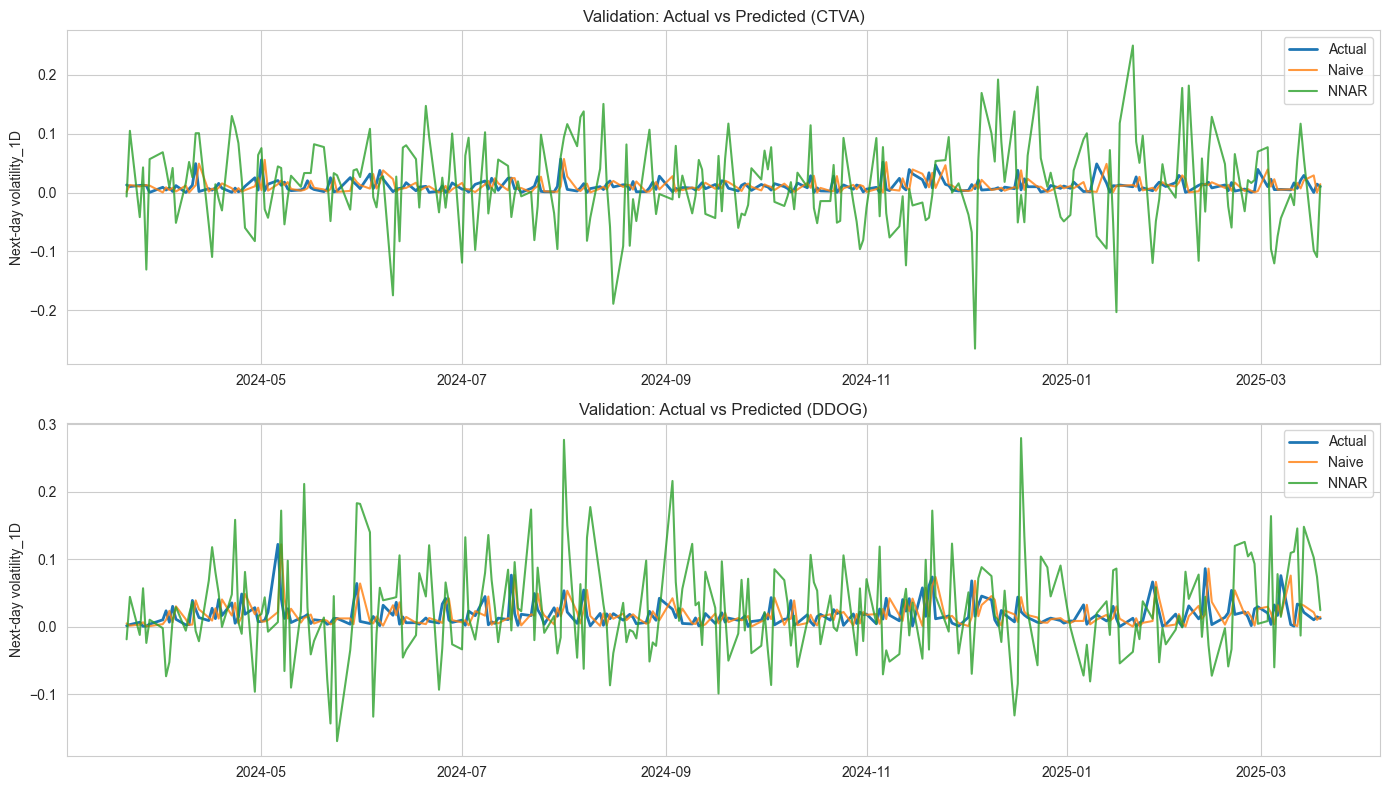

In [44]:
fig, axes = plt.subplots(len(symbols_to_model), 1, figsize=(14, 8), sharex=False)
if len(symbols_to_model) == 1:
    axes = [axes]

for ax, symbol in zip(axes, symbols_to_model):
    p = validation_predictions_df[validation_predictions_df["Symbol"] == symbol]
    ax.plot(p["Date"], p["actual"], label="Actual", linewidth=2)
    ax.plot(p["Date"], p["pred_naive"], label="Naive", alpha=0.8)
    ax.plot(p["Date"], p["pred_nnar"], label="NNAR", alpha=0.8)
    ax.set_title(f"Validation: Actual vs Predicted ({symbol})")
    ax.set_ylabel("Next-day volatility_1D")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

## Validation Plots: Rolling Absolute Error

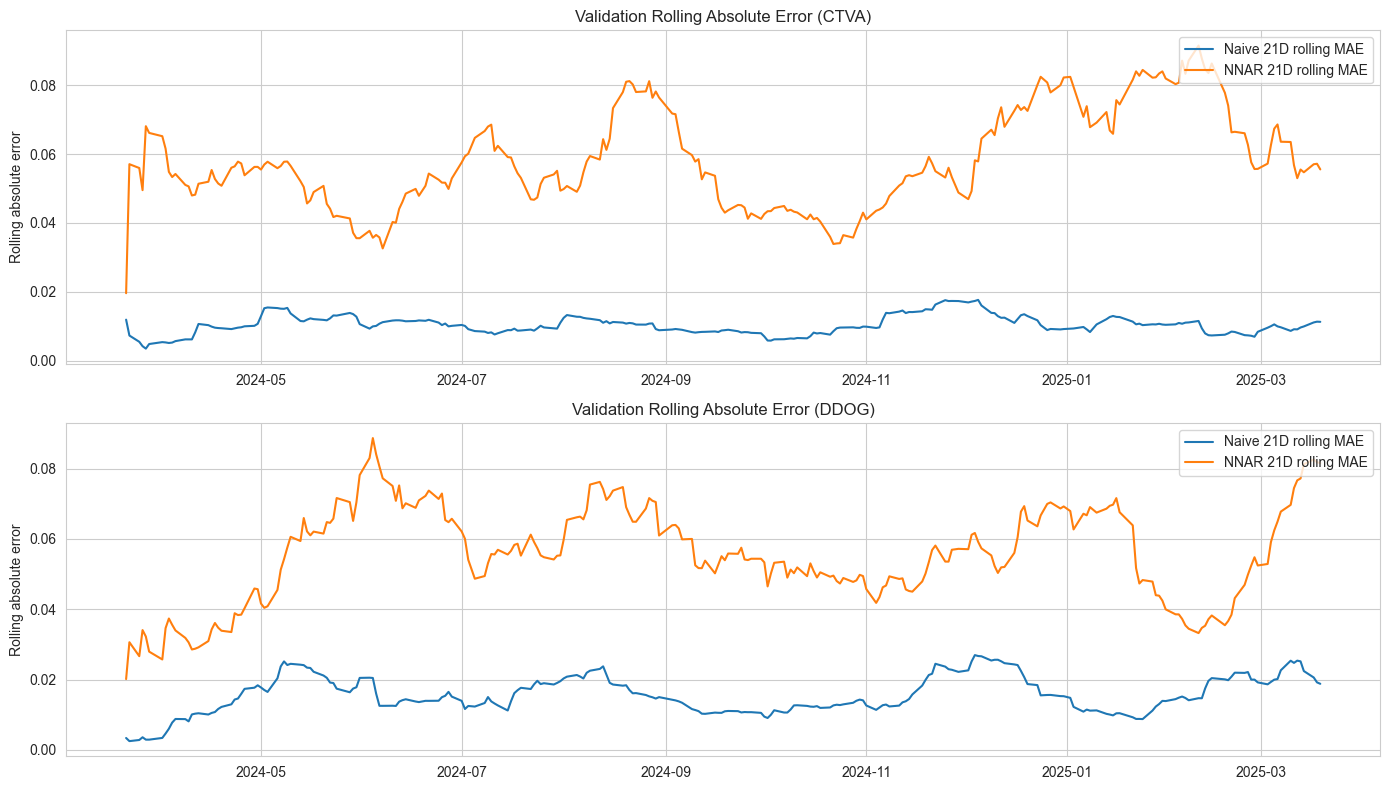

In [45]:
rolling_window = 21

fig, axes = plt.subplots(len(symbols_to_model), 1, figsize=(14, 8), sharex=False)
if len(symbols_to_model) == 1:
    axes = [axes]

for ax, symbol in zip(axes, symbols_to_model):
    p = validation_predictions_df[validation_predictions_df["Symbol"] == symbol].copy()
    p["abs_err_naive"] = np.abs(p["actual"] - p["pred_naive"])
    p["abs_err_nnar"] = np.abs(p["actual"] - p["pred_nnar"])
    p["roll_abs_err_naive"] = p["abs_err_naive"].rolling(rolling_window, min_periods=1).mean()
    p["roll_abs_err_nnar"] = p["abs_err_nnar"].rolling(rolling_window, min_periods=1).mean()

    ax.plot(p["Date"], p["roll_abs_err_naive"], label=f"Naive {rolling_window}D rolling MAE")
    ax.plot(p["Date"], p["roll_abs_err_nnar"], label=f"NNAR {rolling_window}D rolling MAE")
    ax.set_title(f"Validation Rolling Absolute Error ({symbol})")
    ax.set_ylabel("Rolling absolute error")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

## Retrain on Train+Validation and Forecast Unseen

Rules applied:
- Fit a new scaler on train+validation only (per stock).
- Retrain a fresh NNAR model on train+validation.
- Forecast unseen one day ahead sequentially.
- Do not refit model daily.

In [46]:
trainval_raw = df[(df["Date"] >= data_start) & (df["Date"] <= val_end)].copy()
unseen_raw = unseen_reference_small[
    (unseen_reference_small["Date"] >= unseen_start) & (unseen_reference_small["Date"] <= unseen_end)
].copy()

print("trainval_raw shape:", trainval_raw.shape)
print("unseen_raw shape (from unseen_path):", unseen_raw.shape)

trainval_raw shape: (2010, 10)
unseen_raw shape (from unseen_path): (502, 10)


In [47]:
trainval_features = create_engineered_features(
    trainval_raw,
    include_today=include_today,
    use_log_volatility=use_log_volatility,
    n_lags=n_lags
)
trainval_model_df = trainval_features.dropna(subset=feature_cols + [target_col]).copy()

print("trainval_features shape:", trainval_features.shape)
print("trainval_model_df shape:", trainval_model_df.shape)
display(trainval_model_df.head(3))

trainval_features shape: (2010, 41)
trainval_model_df shape: (1964, 41)


,Date,Open,High,Low,Close,Volume,Symbol,Security,Sector,Weight,...,volatility_1D_lag13,volatility_1D_lag14,volatility_1D_lag15,volatility_1D_lag16,volatility_1D_lag17,volatility_1D_lag18,volatility_1D_lag19,volatility_1D_lag20,volatility_1D_lag21,target_next_volatility_1D
22,2021-04-22,45.765937,46.267713,45.150547,45.519783,3445600.0,CTVA,Corteva,Materials,0.0009,...,0.006398,0.002571,0.006841,0.017528,0.002926,0.023868,0.012693,0.007388,0.031135,0.011374
23,2021-04-23,45.529254,46.310325,45.396710,46.040501,2501300.0,CTVA,Corteva,Materials,0.0009,...,0.014771,0.006398,0.002571,0.006841,0.017528,0.002926,0.023868,0.012693,0.007388,0.004923
24,2021-04-26,46.125694,46.712678,46.054687,46.267704,1890000.0,CTVA,Corteva,Materials,0.0009,...,0.020955,0.014771,0.006398,0.002571,0.006841,0.017528,0.002926,0.023868,0.012693,0.005917


In [48]:
# Build unseen features with trailing history from train+validation
# so earliest unseen rows have valid rolling and lag inputs.
history_tail_rows = 80  # comfortably above maximum lookback requirement
unseen_features_parts = []

for symbol in symbols_to_model:
    hist_symbol = trainval_raw[trainval_raw["Symbol"] == symbol].sort_values("Date").tail(history_tail_rows)
    unseen_symbol = unseen_raw[unseen_raw["Symbol"] == symbol].sort_values("Date")

    combined_symbol = pd.concat([hist_symbol, unseen_symbol], axis=0).sort_values("Date").copy()
    combined_symbol["Symbol"] = symbol

    engineered_symbol = create_engineered_features(
        combined_symbol,
        include_today=include_today,
        use_log_volatility=use_log_volatility,
        n_lags=n_lags
    )

    engineered_symbol = engineered_symbol[
        (engineered_symbol["Date"] >= unseen_start) & (engineered_symbol["Date"] <= unseen_end)
    ].copy()

    unseen_features_parts.append(engineered_symbol)

unseen_features = pd.concat(unseen_features_parts, axis=0).sort_values(["Symbol", "Date"]).reset_index(drop=True)
unseen_model_df = unseen_features.dropna(subset=feature_cols + [target_col]).copy()

print("unseen_features shape:", unseen_features.shape)
print("unseen_model_df shape:", unseen_model_df.shape)
display(unseen_model_df.head(3))

unseen_features shape: (502, 41)
unseen_model_df shape: (500, 41)


,Date,Open,High,Low,Close,Volume,Symbol,Security,Sector,Weight,...,volatility_1D_lag13,volatility_1D_lag14,volatility_1D_lag15,volatility_1D_lag16,volatility_1D_lag17,volatility_1D_lag18,volatility_1D_lag19,volatility_1D_lag20,volatility_1D_lag21,target_next_volatility_1D
0,2025-03-21,60.942673,61.338788,60.561408,61.120926,6880500.0,CTVA,Corteva,Materials,0.0009,...,0.009984,0.039125,0.002544,0.000318,0.002862,0.005892,0.002393,0.016905,0.002981,0.005655
1,2025-03-24,61.992384,61.992384,61.051608,61.467529,2117800.0,CTVA,Corteva,Materials,0.0009,...,0.022488,0.009984,0.039125,0.002544,0.000318,0.002862,0.005892,0.002393,0.016905,0.003551
2,2025-03-25,61.477435,61.744811,60.962482,61.249664,2565200.0,CTVA,Corteva,Materials,0.0009,...,0.004917,0.022488,0.009984,0.039125,0.002544,0.000318,0.002862,0.005892,0.002393,0.013649


In [49]:
unseen_records = []
unseen_predictions = []
fitted_scalers_unseen = {}
fitted_models_unseen = {}
histories_unseen = {}

for symbol in symbols_to_model:
    print(f"\n--- Retrain + unseen forecasting for {symbol} ---")

    trainval_s = trainval_model_df[trainval_model_df["Symbol"] == symbol].sort_values("Date").copy()
    unseen_s = unseen_model_df[unseen_model_df["Symbol"] == symbol].sort_values("Date").copy()

    print("Train+Val rows:", len(trainval_s), "| Unseen rows:", len(unseen_s))

    X_tv = trainval_s[feature_cols].values
    y_tv = trainval_s[target_col].values
    X_unseen = unseen_s[feature_cols].values
    y_unseen = unseen_s[target_col].values

    scaler_tv = StandardScaler()
    X_tv_scaled = scaler_tv.fit_transform(X_tv)

    model_tv = build_nnar_model(
        input_dim=X_tv_scaled.shape[1],
        hidden_units=hidden_units,
        activation=activation
    )

    es_tv = EarlyStopping(
        monitor="loss",
        patience=patience,
        restore_best_weights=True
    )

    history_tv = model_tv.fit(
        X_tv_scaled,
        y_tv,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[es_tv],
        verbose=0
    )

    # Sequential one-step-ahead inference (no daily refit)
    nnar_preds = []
    for i in range(len(unseen_s)):
        x_i = X_unseen[i].reshape(1, -1)
        x_i_scaled = scaler_tv.transform(x_i)
        pred_i = model_tv.predict(x_i_scaled, verbose=0).ravel()[0]
        nnar_preds.append(pred_i)

    nnar_preds = np.array(nnar_preds)
    naive_preds = unseen_s["volatility_1D"].values

    naive_metrics = compute_metrics(y_unseen, naive_preds)
    nnar_metrics = compute_metrics(y_unseen, nnar_preds)

    unseen_records.append({
        "Stage": "Unseen",
        "Symbol": symbol,
        "Model": "Naive(today_vol)",
        **naive_metrics
    })
    unseen_records.append({
        "Stage": "Unseen",
        "Symbol": symbol,
        "Model": "NNAR(1 hidden layer)",
        **nnar_metrics
    })

    pred_df = unseen_s[["Date", "Symbol", target_col, "volatility_1D"]].copy()
    pred_df["pred_naive"] = naive_preds
    pred_df["pred_nnar"] = nnar_preds
    pred_df.rename(columns={target_col: "actual"}, inplace=True)
    unseen_predictions.append(pred_df)

    fitted_scalers_unseen[symbol] = scaler_tv
    fitted_models_unseen[symbol] = model_tv
    histories_unseen[symbol] = history_tv


--- Retrain + unseen forecasting for CTVA ---
Train+Val rows: 982 | Unseen rows: 250


E0000 00:00:1775714838.533393 18610519 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
E0000 00:00:1775714843.553057 18610519 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type


--- Retrain + unseen forecasting for DDOG ---
Train+Val rows: 982 | Unseen rows: 250


E0000 00:00:1775714854.336440 18610519 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
E0000 00:00:1775714859.372049 18610519 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type

In [50]:
unseen_metrics_df = pd.DataFrame(unseen_records)
unseen_predictions_df = pd.concat(unseen_predictions, axis=0).sort_values(["Symbol", "Date"]).reset_index(drop=True)

print("Unseen metrics:")
display(unseen_metrics_df.sort_values(["Symbol", "Model"]))

print("Unseen predictions head:")
display(unseen_predictions_df.head(5))

Unseen metrics:


,Stage,Symbol,Model,RMSE,MAE,MSE,Corr,sMAPE
1,Unseen,CTVA,NNAR(1 hidden layer),0.102349,0.070794,0.010475,0.062584,162.452913
0,Unseen,CTVA,Naive(today_vol),0.016783,0.010460,0.000282,0.070118,92.253878
3,Unseen,DDOG,NNAR(1 hidden layer),0.075865,0.055645,0.005756,0.036280,136.136689
2,Unseen,DDOG,Naive(today_vol),0.034946,0.021325,0.001221,0.049131,90.301064


Unseen predictions head:


,Date,Symbol,actual,volatility_1D,pred_naive,pred_nnar
0,2025-03-21,CTVA,0.005655,0.001781,0.001781,0.033346
1,2025-03-24,CTVA,0.003551,0.005655,0.005655,-0.109055
2,2025-03-25,CTVA,0.013649,0.003551,0.003551,-0.130406
3,2025-03-26,CTVA,0.004155,0.013649,0.013649,-0.016816
4,2025-03-27,CTVA,0.022349,0.004155,0.004155,0.020127


## Unseen Plots: Actual vs Predicted

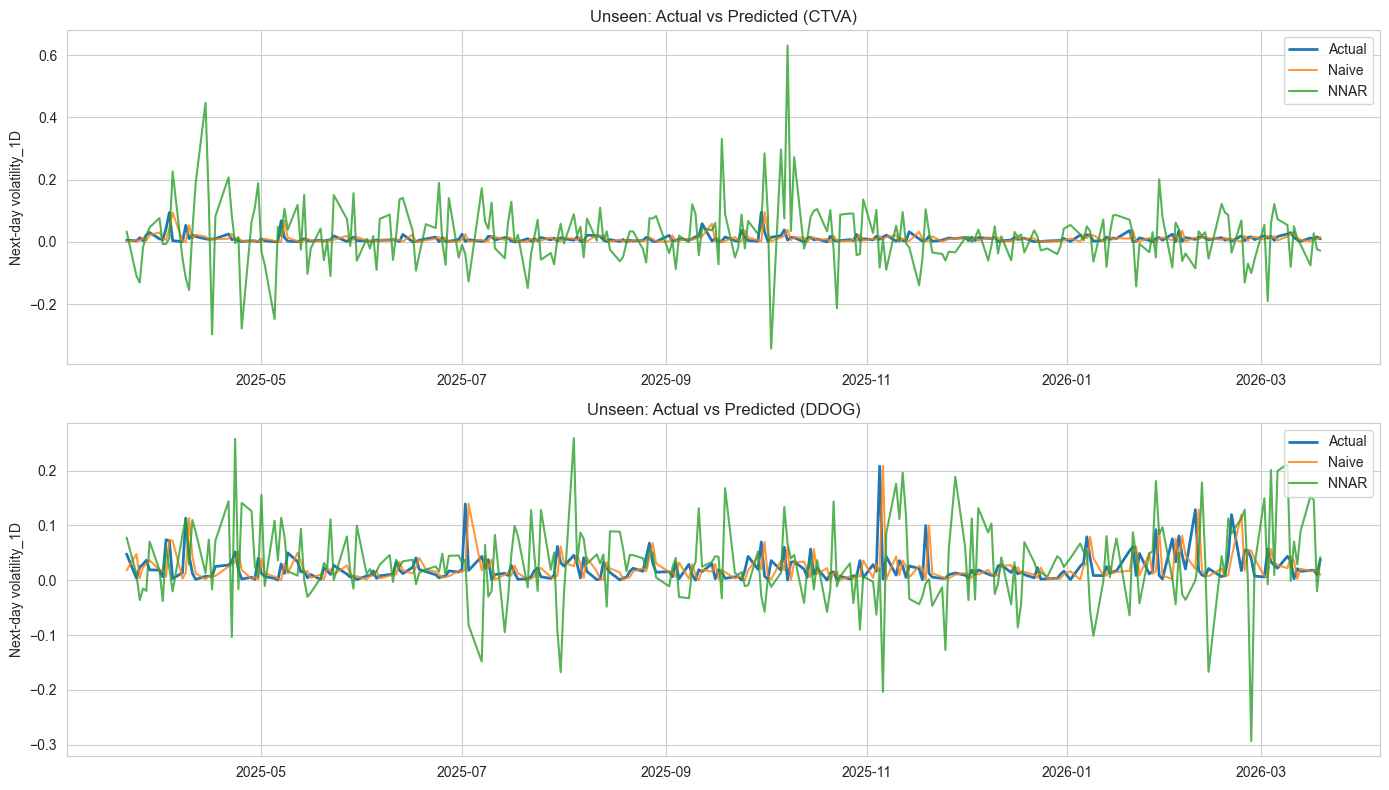

In [51]:
fig, axes = plt.subplots(len(symbols_to_model), 1, figsize=(14, 8), sharex=False)
if len(symbols_to_model) == 1:
    axes = [axes]

for ax, symbol in zip(axes, symbols_to_model):
    p = unseen_predictions_df[unseen_predictions_df["Symbol"] == symbol]
    ax.plot(p["Date"], p["actual"], label="Actual", linewidth=2)
    ax.plot(p["Date"], p["pred_naive"], label="Naive", alpha=0.8)
    ax.plot(p["Date"], p["pred_nnar"], label="NNAR", alpha=0.8)
    ax.set_title(f"Unseen: Actual vs Predicted ({symbol})")
    ax.set_ylabel("Next-day volatility_1D")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

## Unseen Plots: Rolling Absolute Error

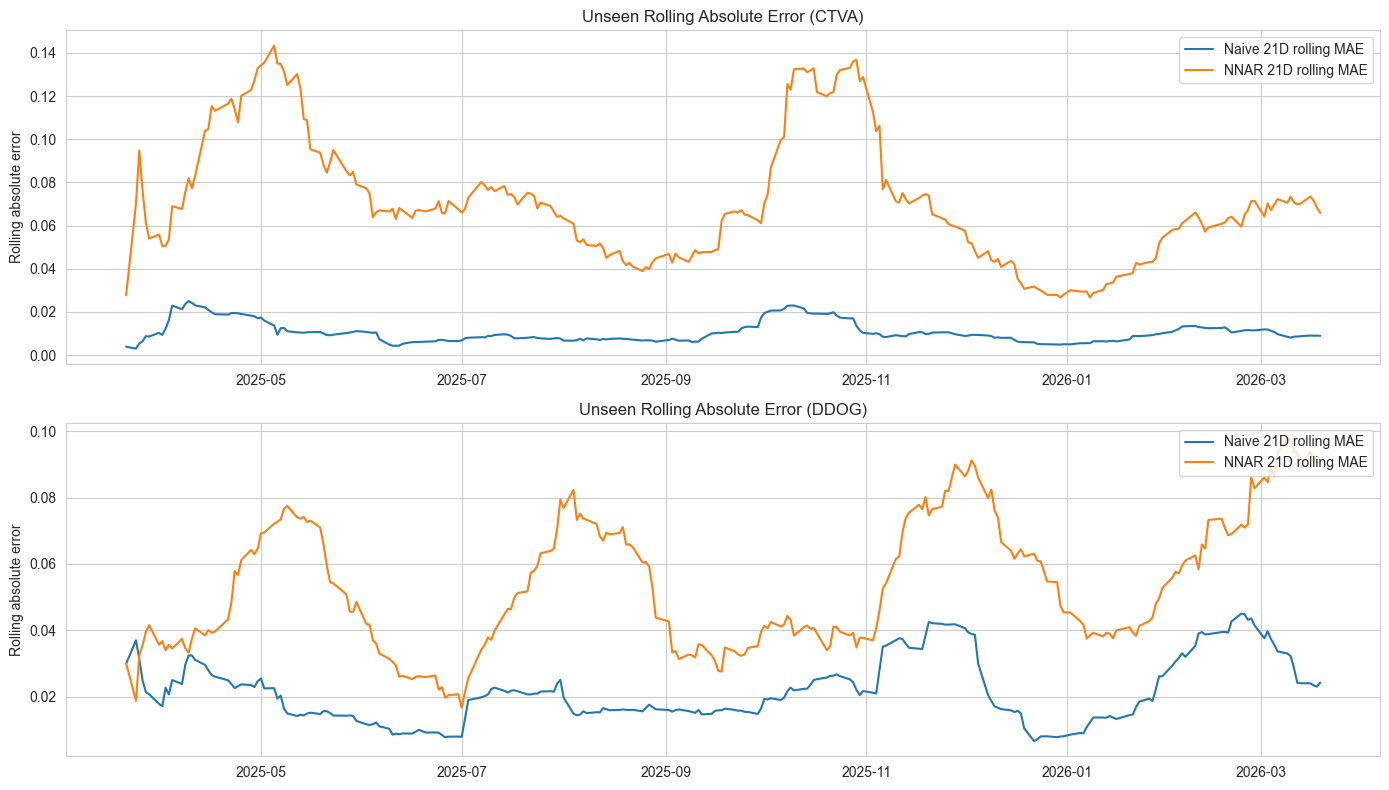

In [52]:
rolling_window = 21

fig, axes = plt.subplots(len(symbols_to_model), 1, figsize=(14, 8), sharex=False)
if len(symbols_to_model) == 1:
    axes = [axes]

for ax, symbol in zip(axes, symbols_to_model):
    p = unseen_predictions_df[unseen_predictions_df["Symbol"] == symbol].copy()
    p["abs_err_naive"] = np.abs(p["actual"] - p["pred_naive"])
    p["abs_err_nnar"] = np.abs(p["actual"] - p["pred_nnar"])
    p["roll_abs_err_naive"] = p["abs_err_naive"].rolling(rolling_window, min_periods=1).mean()
    p["roll_abs_err_nnar"] = p["abs_err_nnar"].rolling(rolling_window, min_periods=1).mean()

    ax.plot(p["Date"], p["roll_abs_err_naive"], label=f"Naive {rolling_window}D rolling MAE")
    ax.plot(p["Date"], p["roll_abs_err_nnar"], label=f"NNAR {rolling_window}D rolling MAE")
    ax.set_title(f"Unseen Rolling Absolute Error ({symbol})")
    ax.set_ylabel("Rolling absolute error")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

## Metric Summary Tables

In [53]:
all_metrics_df = pd.concat([validation_metrics_df, unseen_metrics_df], axis=0).reset_index(drop=True)
all_metrics_df = all_metrics_df.sort_values(["Stage", "Symbol", "Model"]).reset_index(drop=True)

print("All metrics long-form:")
display(all_metrics_df)

print("Metrics pivot (RMSE):")
display(
    all_metrics_df.pivot_table(
        index=["Stage", "Symbol"],
        columns="Model",
        values="RMSE"
    )
)

All metrics long-form:


,Stage,Symbol,Model,RMSE,MAE,MSE,Corr,sMAPE
0,Unseen,CTVA,NNAR(1 hidden layer),0.102349,0.070794,0.010475,0.062584,162.452913
1,Unseen,CTVA,Naive(today_vol),0.016783,0.010460,0.000282,0.070118,92.253878
2,Unseen,DDOG,NNAR(1 hidden layer),0.075865,0.055645,0.005756,0.036280,136.136689
3,Unseen,DDOG,Naive(today_vol),0.034946,0.021325,0.001221,0.049131,90.301064
4,Validation,CTVA,NNAR(1 hidden layer),0.073393,0.058113,0.005387,0.053530,163.292659
5,Validation,CTVA,Naive(today_vol),0.014867,0.010580,0.000221,-0.032664,95.464999
6,Validation,DDOG,NNAR(1 hidden layer),0.073129,0.057491,0.005348,0.029760,153.250588
7,Validation,DDOG,Naive(today_vol),0.022630,0.016269,0.000512,0.122137,91.981621


Metrics pivot (RMSE):


Model              NNAR(1 hidden layer)  Naive(today_vol)
Stage      Symbol                                        
Unseen     CTVA                0.102349          0.016783
           DDOG                0.075865          0.034946
Validation CTVA                0.073393          0.014867
           DDOG                0.073129          0.022630

## Final Data Checks and Samples

In [54]:
print("Train rows by stock:")
display(train_df.groupby("Symbol").size().rename("rows").reset_index())

print("Validation rows by stock:")
display(val_df.groupby("Symbol").size().rename("rows").reset_index())

print("Unseen rows by stock (model-ready):")
display(unseen_model_df.groupby("Symbol").size().rename("rows").reset_index())

Train rows by stock:


,Symbol,rows
0,CTVA,733
1,DDOG,733


Validation rows by stock:


,Symbol,rows
0,CTVA,249
1,DDOG,249


Unseen rows by stock (model-ready):


,Symbol,rows
0,CTVA,250
1,DDOG,250


In [55]:
print("Validation prediction sample:")
display(validation_predictions_df.groupby("Symbol").head(3))

print("Unseen prediction sample:")
display(unseen_predictions_df.groupby("Symbol").head(3))

Validation prediction sample:


,Date,Symbol,actual,volatility_1D,pred_naive,pred_nnar
0,2024-03-21,CTVA,0.012810,0.000897,0.000897,-0.006783
1,2024-03-22,CTVA,0.010118,0.012810,0.012810,0.104635
2,2024-03-25,CTVA,0.011972,0.010118,0.010118,-0.041750
249,2024-03-21,DDOG,0.001301,0.004710,0.004710,-0.018855
250,2024-03-22,DDOG,0.002931,0.001301,0.001301,0.044038
251,2024-03-25,DDOG,0.006420,0.002931,0.002931,-0.012319


Unseen prediction sample:


,Date,Symbol,actual,volatility_1D,pred_naive,pred_nnar
0,2025-03-21,CTVA,0.005655,0.001781,0.001781,0.033346
1,2025-03-24,CTVA,0.003551,0.005655,0.005655,-0.109055
2,2025-03-25,CTVA,0.013649,0.003551,0.003551,-0.130406
250,2025-03-21,DDOG,0.047779,0.017868,0.017868,0.077831
251,2025-03-24,DDOG,0.003715,0.047779,0.047779,0.011125
252,2025-03-25,DDOG,0.023886,0.003715,0.003715,-0.036034


## Notes

- Separate model trained per stock (`CTVA`, `DDOG`).
- Target is next-day `volatility_1D`.
- Feature generation and scaling follow leakage-safe rules.
- Validation is used for model assessment.
- Final unseen predictions are made sequentially without daily refits.